## Figure 2 and Figure S3 — Bloch waves in the narrow-pass-band regime

This notebook reproduces **Figure 2** and **Figure S3** of the paper.

The periodic medium has Helmholtz coefficient
$$F(x) = C_0 + C_1\cos\!\left(\frac{2\pi x}{\lambda}\right)$$
with $\eta = C_1/|C_0| > 1$ so that $F(x)$ is **almost everywhere negative**.
Propagating Bloch solutions then exist only in exponentially narrow frequency bands,
and their dispersion law maps onto the Transmon / QHO eigenvalue problem.


In [1]:
import numpy as np
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

In [2]:
def equation_lin(t, y, toto, titi):  
    qq, pp  = y
    #dydt = [pp, -(toto-2*titi*np.cos(2*t))*qq]
    dydt = [pp, -(toto+2*titi*np.cos(2*t))*qq]
    return dydt


In [3]:
def find(element, vector):
    
    """ Function returning index of an element in a vector """
    
    for i in range(len(vector)):
        if vector[i] == element:
            return (i)

In [4]:
def compute_energy(fft_wave, k):
    # Compute the squared amplitude of the FFT (energy density in Fourier space)
    amplitude_squared = np.abs(fft_wave)**2
    
    # Compute the spacing in k-space (assumes uniform sampling in k)
    dk = np.abs(k[1] - k[0])  # Assumes k is sorted and evenly spaced
    
    # Integrate energy density over all wavenumbers
    total_energy = np.sum(amplitude_squared) * dk
    
    return total_energy

In [5]:
def sol_comp_mode_floquet(t, y, a, q, sn):
    JJ = np.array([ [0.,1 ],
                       [-(a+2*q*np.cos(2*t)),0.] ],dtype=complex)
    Is = np.array([ [sn,0.],
                       [0.,sn] ],dtype=complex)
    mat_B   = JJ - Is 
    dydt    = np.dot(mat_B,y)
    return dydt



In [6]:
from scipy.signal import find_peaks

def find_fft_peaks(fft_wave_shifted, k, height=None, distance=None):
    """
    Find the peaks of the FFT and their corresponding wavenumbers.
    
    Parameters:
    - fft_wave_shifted (np.ndarray): The shifted FFT amplitude array.
    - k (np.ndarray): The wavenumbers corresponding to the FFT.
    - height (float, optional): Minimum amplitude for a peak. Default is None.
    - distance (int, optional): Minimum distance between peaks in indices. Default is None.
    
    Returns:
    - peak_k (np.ndarray): Wavenumbers corresponding to the peaks.
    - peak_amplitudes (np.ndarray): Amplitudes of the peaks.
    """
    # Find peaks in the FFT amplitude
    peaks, _ = find_peaks(np.abs(fft_wave_shifted), height=height, distance=distance)
    
    # Extract wavenumbers and amplitudes at the peaks
    peak_k = k[peaks]
    peak_amplitudes = np.abs(fft_wave_shifted[peaks])
    
    # Return unique peaks sorted by wavenumber
    unique_indices = np.argsort(peak_k)
    return peak_k[unique_indices], peak_amplitudes[unique_indices]

In [7]:
def compute_hill_eigenvalues1(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    Hmax = 20
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute eigenvalues and eigenvectors
    eigtot, V = np.linalg.eig(HILL)
    eigtot = eigtot[np.argsort(np.imag(eigtot))]  # Sort eigenvalues by imaginary part

    # Weighted arithmetic mean (center of mass) calculation
    XX = np.repeat(np.arange(-Hmax, Hmax + 1), nstate)
    abs_V = np.abs(V)
    Wmean = np.sum(XX[:, None] * abs_V, axis=0) / np.sum(abs_V, axis=0)

    # Sort by weighted arithmetic mean
    sorted_indices = np.argsort(Wmean)
    Wmean_sorted = Wmean[sorted_indices]

    # Filter based on balanced eigenvectors
    ind2 = np.where((np.round(Wmean_sorted, 6) <= 0.5) & (np.round(Wmean_sorted, 6) > -0.5))[0]

    # Select the most converged eigenvalues and eigenvectors
    if len(ind2) == nstate:
        # Further sort by the absolute imaginary part of eigenvalues
        ind3 = np.argsort(np.abs(np.imag(eigtot[sorted_indices[ind2]])))
        Fexponents = eigtot[sorted_indices[ind2[ind3]]]
        VecHill = V[:, sorted_indices[ind2[ind3]]]
    else:
        # If not enough converged eigenvalues, return NaN arrays
        Fexponents = np.full((nstate,), np.nan + 1j * np.nan)
        VecHill = np.full((nstate * (2 * Hmax + 1), nstate), np.nan + 1j * np.nan)

    return Fexponents, VecHill


In [8]:
def compute_hill_eigenvalues2(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    solfinal = np.zeros(nstate, dtype=complex)
    Hmax = 12
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute the eigenvalues
    eighill = np.linalg.eigvals(HILL)
    
    # Filter eigenvalues based on the imaginary part condition
    condition = np.abs(np.imag(eighill)) < (np.pi / TT + 10**(-Hmax))
    solhill = eighill[condition]
    
    if solhill.size == nstate:
        solfinal = solhill
    elif solhill.size == 2*nstate:
        solfinal[0] = np.abs(np.real(solhill[0])) + 1j*np.abs(np.imag(solhill[0]))
        solfinal[1] = -solfinal[0]
            
    return solfinal

In [9]:
def equation_a(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_a(nn, q) - (2 * s0 * q / s1)

def equation_b(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_b(nn, q) - (2 * s0 * q / s1)

def solve_mathieu(nn, s0, s1, initial_guesses,xtol=1e-18, maxfev=10000,factor=0.2):
    """Finds solutions for the Mathieu equation with given s0 and s1."""
    solutiona = []
    solutionb = []
    for guess in initial_guesses:
        sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        if not any(np.isclose(sola, solutiona, atol=1e-15)):  # Avoid duplicate roots
            solutiona.append(sola)
        if not any(np.isclose(solb, solutionb, atol=1e-15)):  # Avoid duplicate roots
            solutionb.append(solb)    
    return [solutiona,solutionb]


### Floquet stability map — computation (saves `Map_rho_H12_negative.npy`)

Scans the $(a,\,q)$ Mathieu parameter plane and computes the Floquet multipliers
$\rho_{1,2}$ of the monodromy matrix. **Heavy computation — skip if `Map_rho_H12_negative.npy` is already on disk.**


In [ ]:
# Define the range of q values
qq = np.linspace(0, 40, 500)
aa = np.linspace(-32, 20, 500)

mat_row = np.size(aa)
mat_col = np.size(qq)
matrho1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho1[:] = np.NaN
matrho2[:] = np.NaN

mats1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats1[:] = np.NaN
mats2[:] = np.NaN


for qi in qq:
    kk   = find(qi, qq)

    for ai in aa:
        ll = find(ai, aa)

        #if sqrtEtilde < sqrtDVtilde:
        eigenvalues = compute_hill_eigenvalues2(ai, qi, np.pi)   
        #print(eigenvalues)
        
        mats1[ll,kk]       = eigenvalues[0]
        mats2[ll,kk]       = eigenvalues[1]
                   
        matrho1[ll,kk]       = np.exp(eigenvalues[0]*np.pi)
        matrho2[ll,kk]       = np.exp(eigenvalues[1]*np.pi)


In [496]:
with open('Map_rho_H12_negative.npy', 'wb') as f:
    np.save(f, aa)
    np.save(f, qq)
    np.save(f, matrho1)
    np.save(f, matrho2)
    np.save(f, mats1)
    np.save(f, mats2)

### Floquet stability map — load and extract pass-band boundaries

Loads the precomputed map and solves for Mathieu characteristic values
$a_n(q)$, $b_n(q)$ delimiting each pass band (`listqa`, `listqb`).


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_63686/1540144603.py:14: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_63686/1540144603.py:15: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_63686/1540144603.py:14: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn

[  1.64607477  18.20265375  50.98080847 100.14607039 165.69946966
 247.64112587 345.97107399 460.68932732 591.79589181 739.29077047] [  1.91484147  18.20341283  50.98080996 100.14607039 165.69946966
 247.64112587 345.97107399 460.68932732 591.79589181 739.29077047]


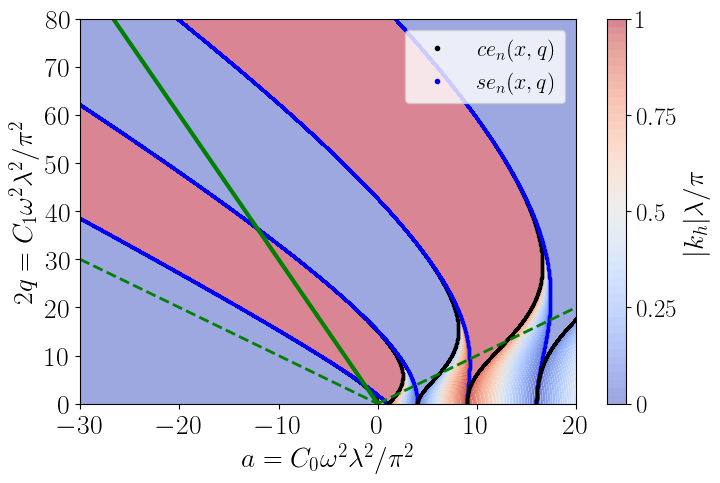

In [10]:
pent = 3
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
s0 = -eps0*mu0
s1=-pent*s0


with open('Map_rho_H12_negative.npy', 'rb') as f:
    aanum = np.load(f)
    qqnum = np.load(f)
    matrho1 = np.load(f)
    matrho2 = np.load(f)
    mats1 = np.load(f)
    mats2 = np.load(f)    

matrho = np.maximum(np.abs(matrho1), np.abs(matrho2))
realsmax = np.maximum(np.real(mats1), np.real(mats2))
#print(realsmax.shape)

mat_row = np.size(aanum)
mat_col = np.size(qqnum)    
    
aanum.shape=(1,mat_row)
qqnum.shape=(1,mat_col)

Mq = np.dot(np.transpose(aanum),np.ones((1,mat_col)))
Mp = np.dot(np.ones((mat_row,1)),qqnum)


imax = 10
listqa = np.ones(imax)
listqb = np.ones(imax)

for ii in range(imax):
    #print(ii)
    [solutiona,solutionb] = solve_mathieu(ii, s0, s1, [2100])
    #[solutiona,solutionb] = solve_mathieu(ii, s0a, s1a, [(s1a/2)*(2*ii+1)**2*test**2*lamba**2/np.pi**2])
    solutiona = solutiona[0]
    solutionb = solutionb[0]
    #[solutiona,solutionb] = solve_with_min(ii, s0a, s1a, (ii*10,1000*ii))
    #[solutiona,solutionb] = solve_with_newton(ii, s0a, s1a, (s1a/2)*(2*ii+1)**2*test**2*lamba**2/np.pi**2)
    #solutiona = solutiona[0]
    #solutionb = solutionb[0]    
    #print(solutiona,solutionb)
    listqa[ii] = solutiona
    listqb[ii] = solutionb
    
print(listqa,listqb)

# Define the range of q values
qq = np.linspace(-50, 50, 10000)
aa = np.linspace(-100, 100, 10000)


# Calculate Mathieu function characteristic values
A0e = [mathieu_a(n, qq) for n in range(5)]  # Even modes
A0o = [mathieu_b(n, qq) for n in range(1, 6)]  # Odd modes

# Set font size for plots
fonty = 20
levelou = np.linspace(0.01,(np.amax(np.asarray(realsmax))),100)
leveli = np.linspace(-0.0001,1+0.0001,50)


fig1 = plt.figure(1, figsize=(8, 5))
plt.rc('text', usetex=True)

# Plot characteristic curves with swapped axes
colors = ['k', 'b']
for i, (a, b) in enumerate(zip(A0e, A0o)):
    plt.plot(a, 2*qq, f'{colors[0]}.', markersize=2.5)
    plt.plot(b, 2*qq, f'{colors[1]}.', markersize=2.5)
    
plt.plot(np.NaN, np.NaN, f'{colors[0]}.', markersize=6., label=r'$ce_n(x,q)$')
plt.plot(np.NaN, np.NaN, f'{colors[1]}.', markersize=6., label=r'$se_n(x,q)$')


#sc = plt.scatter(Mq, Mp, c=realsmax, cmap=plt.cm.coolwarm, s=marker_size, alpha=alphadata)
#sc = plt.contourf(Mq,2*Mp,realsmax, cmap=plt.cm.coolwarm,levels=levelou,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,realsmax, 100,cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2))*(Mq+Mp)/2,100, cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.6)
sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.5)


# Colorbar
cbar = plt.colorbar(sc, format='%.1f')

# Set colorbar label and font size
cbar.set_label(r'$|k_h|\lambda/\pi$', fontsize=fonty)  # Adjust font size as needed

# Define the tick locations and corresponding labels
tick_locations = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r'$0$', r'$0.25$', r'$0.5$', r'$0.75$', r'$1$']

# Set the ticks and labels
cbar.set_ticks(tick_locations)
cbar.set_ticklabels(tick_labels)

# Set tick parameters for font size
cbar.ax.tick_params(labelsize=fonty-2)  # Adjust font size as needed



# Fill stability regions with swapped axes
#plt.fill_betweenx(2*qq, -100 * np.ones(qq.size), A0e[0], facecolor='b', alpha=0.5)
#for i in range(1, len(A0e)):
#    plt.fill_betweenx(2*qq, A0o[i-1], A0e[i], facecolor='g' if i % 2 else 'b', alpha=0.5)


plt.plot(aa, 2*aa*s1/(2*s0), 'g-',linewidth=3) 
#plt.plot(aa, 2*aa*0.6/2, 'k-',linewidth=2)
plt.plot([0.,100.],[0.,100.], 'g--',linewidth=2) 
plt.plot([-30.,0.],[30.,0.], 'g--',linewidth=2) 
#plt.plot(aa, -aa*s1/(2*s0), 'k-') 
    
# Customize axes
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$a=C_0\omega^2\lambda^2/\pi^2$', fontsize=fonty)  # x-axis: a
plt.ylabel(r'$2q=C_1\omega^2\lambda^2/\pi^2$', fontsize=fonty)  # y-axis: q
plt.xlim(-30, 20.)
plt.ylim(0.,80.)
#plt.grid()
plt.xscale('linear')
plt.yscale('linear')

# Add legend
plt.legend(fontsize=fonty-4, loc='upper right')

# Show and save the plot
fig1 = plt.gcf()
plt.show()

fig1.savefig('Mathieu_stability_chart_aq_negative.png', format='png', dpi=1000, bbox_inches='tight')

### Dispersion data along pass-band edges

Evaluates Hill-matrix eigenvalues along the physical locus $a = 2s_0 q/s_1$
to build the Bloch-wave dispersion data used in Figure S3.


In [11]:
# Parameters

TT = np.pi

#omega = np.linspace(0.1,10,500)
#aaa = s0*omega**2*lamb**2/np.pi**2
# Define the regions and spacing
qq1 = np.linspace(0.01, listqa[0], 100)
qq2 = np.linspace(qq1[-1], listqb[0], 200)
qq3 = np.linspace(qq2[-1], listqa[1], 100)
qq4 = np.linspace(qq3[-1], listqb[1], 200)
qq5 = np.linspace(qq4[-1], listqa[2], 100)
qq6 = np.linspace(qq5[-1], listqb[2], 200)
qq7 = np.linspace(qq6[-1], listqa[3], 100)
qq8 = np.linspace(qq7[-1], listqb[3], 200)
qq9 = np.linspace(qq8[-1], listqa[4], 100)
qq10 = np.linspace(qq9[-1], listqb[4], 200)
qq11 = np.linspace(qq10[-1], listqa[5], 100)
qq12 = np.linspace(qq11[-1], listqb[5], 200)
qq13 = np.linspace(qq12[-1], listqa[6], 100)
qq14 = np.linspace(qq13[-1], listqb[6], 200)
# Combine all regions
qqq = np.concatenate([qq1, qq2, qq3, qq4, qq5, qq6, qq7, qq8, qq9, qq10, qq11, qq12, qq13, qq14])
aaa = 2*s0*qqq/s1

fexp1 = np.ones(aaa.size,dtype=complex)
fexp2 = np.ones(aaa.size,dtype=complex)
y_1 = [1., 0.0]
y_2 = [0.0, 1.]
inc = -1
for avis in aaa:
    inc = inc + 1
    # The resolution of the ODE needs to be very accurate DOP853 and Radau seem to do a good job
    eigenvalues, vecHill = compute_hill_eigenvalues1(avis, qqq[inc], TT)
    #eigenvalues = compute_hill_eigenvalues2(avis, qqq[inc], TT)
    #print(eigenvalues)
    fexp1[inc]       = eigenvalues[0]
    fexp2[inc]       = eigenvalues[1]


### → Figure 2

**Left**: profile of $F(x) = C_0 + C_1\cos(2\pi x/\lambda)$ in the negative regime
($C_0 = -\varepsilon_0\mu_0$, $\eta = C_1/|C_0| = 3 > 1$).

**Right**: Mathieu/Floquet stability chart in the $(q,\,a)$ plane with pass bands (white)
and stop bands (shaded). The operating locus $a = 2s_0 q/s_1$ is overlaid to locate
the narrow pass-band regime and the quantized frequency sequence.


1.1126500560536185e-17 1.1126264540484579e-17


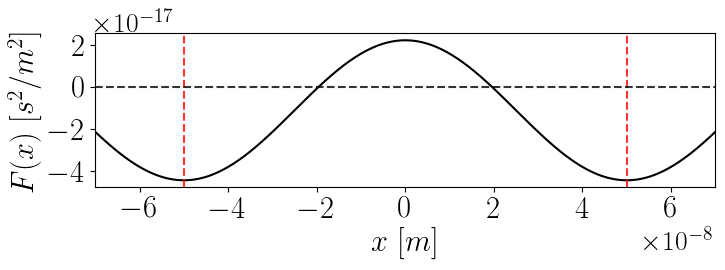

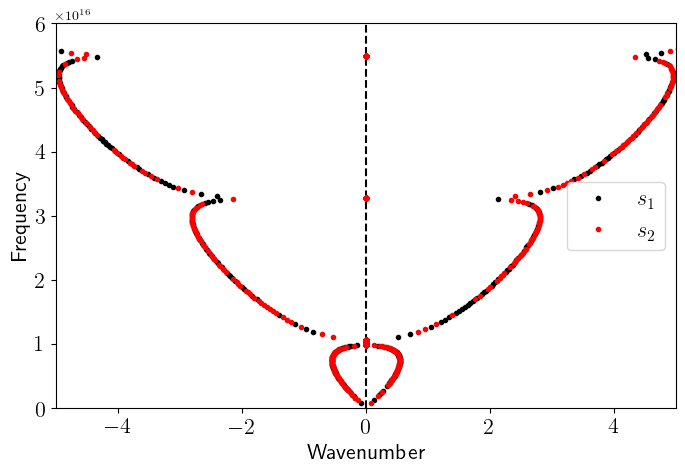

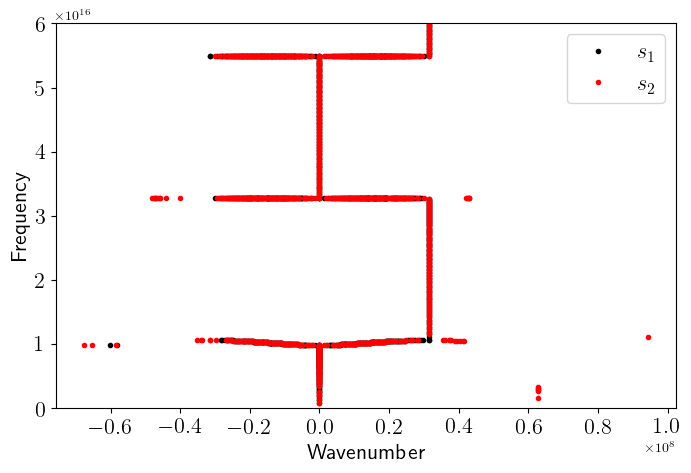

[-40. -40. -40. ...  nan  nan  nan] [6.66666667e-03 1.76840052e-02 2.87013437e-02 ... 2.30647383e+02
 2.30647383e+02 2.30647383e+02]


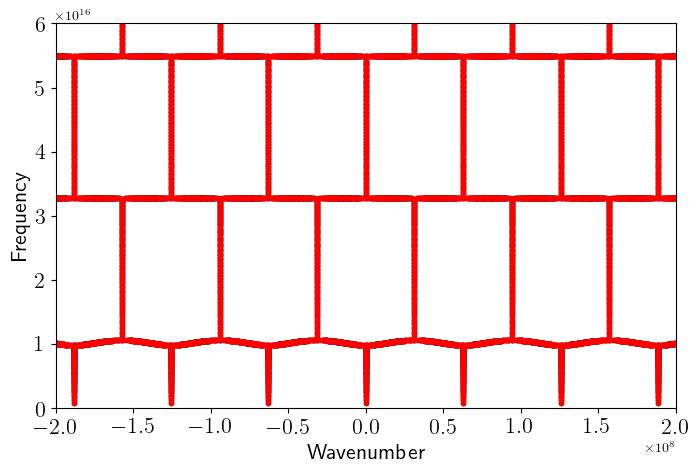

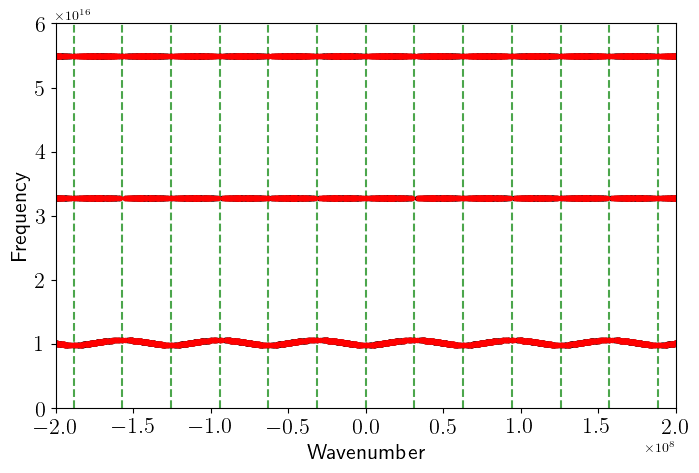

In [12]:
#ymax = 1.05*np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)
ymax = 6e16
lamb = 1*100e-9
kmax = 2e8
vv = 299792458
#vv = vv + 15700000
aap = np.abs(aaa)
print(1/vv**2,eps0*mu0)


xplot = np.linspace(-2*lamb,2*lamb,1000)
yplot = -eps0*mu0+pent*eps0*mu0*np.cos(2*np.pi*xplot/lamb)

fonty = 22
fig1 = plt.figure(1, figsize=(8, 2.))
plt.rc('text', usetex=True)

plt.plot(xplot,yplot,'k-')
plt.axvline(x=-lamb/2, color='r', linestyle='--', alpha=0.8)
plt.axvline(x=lamb/2, color='r', linestyle='--', alpha=0.8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$x$ $[m]$',fontsize=fonty)
plt.ylabel(r'$F(x)$ $[s^2/m^2]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-lamb/2-lamb/5, lamb/2+lamb/5)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Modulation_negative.png', format='png', dpi=1000, bbox_inches='tight')


fonty = 16
fig3 = plt.figure(3, figsize=(8, 5))

#plt.plot([-0.3, 0.3],[0., 0.],'k--')
plt.plot([0., 0.],[0., np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)],'k--')
plt.plot(np.real(fexp1), np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb, 'k.',label=r'$s_1$',linewidth=2.)
plt.plot(np.real(fexp2), np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb, 'r.',label=r'$s_2$',linewidth=2.)
legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel('Wavenumber',fontsize=fonty)
plt.ylabel('Frequency',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-5, 5)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

#fig3.savefig('Floquet_chart2.png', format='png', dpi=1000,bbox_inches='tight')



fonty = 16
fig3 = plt.figure(3, figsize=(8, 5))

#plt.plot([0,kmax], [0,vv*kmax], 'b-',linewidth=2.)
plt.plot(np.pi*np.imag(fexp1)/lamb, np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb, 'k.',label=r'$s_1$',linewidth=2.)
plt.plot(np.pi*np.imag(fexp2)/lamb, np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb, 'r.',label=r'$s_2$',linewidth=2.)
legend = plt.legend(fontsize=fonty,loc='upper right')
plt.xlabel('Wavenumber',fontsize=fonty)
plt.ylabel('Frequency',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#plt.xlim(xliminf-TT/2., xlimsup-TT/2.)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()




shift_range = np.arange(-20, 20)  # Shifts from -3 to 3, including 0
# Generalized concatenation
eigtot1ext = np.concatenate([np.imag(fexp1) + k*2 for k in shift_range])
eigtot2ext = np.concatenate([np.imag(fexp2) + k*2 for k in shift_range])
aaext = np.tile(aap, len(shift_range))  # Use len() instead of np.length()

print(eigtot1ext, aaext)


fonty = 16
fig3 = plt.figure(3, figsize=(8, 5))

plt.plot(np.pi*eigtot1ext/lamb, np.pi*np.sqrt(aaext)/np.sqrt(np.abs(s0))/lamb, 'k.',linewidth=2.)
plt.plot(np.pi*eigtot2ext/lamb, np.pi*np.sqrt(aaext)/np.sqrt(np.abs(s0))/lamb, 'r.',linewidth=2.)
#plt.plot([0,kmax], [0,vv*kmax], 'b-',linewidth=2.)
#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel('Wavenumber',fontsize=fonty)
plt.ylabel('Frequency',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-kmax, kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()



toto1 = np.where(np.abs(np.real(fexp1))<1e-3)
fexp1sort = fexp1[toto1]
aasort1 = aap[toto1]
toto2 = np.where(np.abs(np.real(fexp2))<1e-3)
fexp2sort = fexp2[toto2]
aasort2 = aap[toto2]
aaextsort1 = np.tile(aasort1, len(shift_range))  # Use len() instead of np.length()
aaextsort2 = np.tile(aasort2, len(shift_range))  # Use len() instead of np.length()

eigtot1extsort = np.concatenate([np.imag(fexp1sort) + k*2 for k in shift_range])
eigtot2extsort = np.concatenate([np.imag(fexp2sort) + k*2 for k in shift_range])

num_lines = 8
fonty = 16
fig3 = plt.figure(3, figsize=(8, 5))

# Add vertical dashed lines
for i in range(-1-num_lines, num_lines + 1):
    x_pos = i * np.pi / lamb
    plt.axvline(x=x_pos, color='g', linestyle='--', alpha=0.7)

plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'k.',linewidth=2.)
plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'r.',linewidth=2.)
#plt.plot([0,kmax], [0,vv*kmax], 'b-',linewidth=2.)
#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel('Wavenumber',fontsize=fonty)
plt.ylabel('Frequency',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-kmax, kmax)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

### → Figure S3 — Bloch wave profiles for modes $n = 0, 1, 2$

Integrates the Mathieu ODE for the three lowest pass-band frequencies.
Each cell corresponds to one mode index and produces one panel of Figure S3.


1.0087561461057304e+16
(0.5293253089494664+0.8484189515242773j) (0.5293253089494664-0.8484189515242774j)


/Users/Arnaud/anaconda3/lib/python3.11/site-packages/scipy/integrate/_ivp/rk.py:505: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  super().__init__(fun, t0, y0, t_bound, max_step, rtol, atol,


1.0261135764913626e+16
(0.10718976510854922+0.9942385801486402j) (0.1071897651085493-0.9942385801486399j)


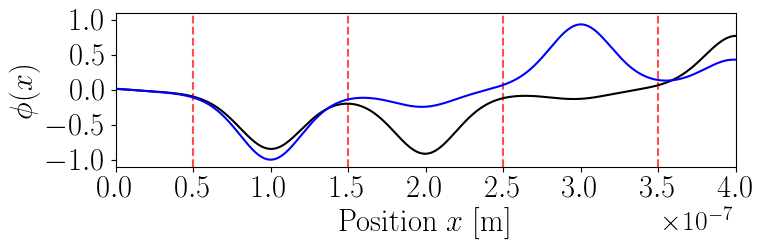

In [13]:
lamb = 100e-9
modevis = 0
nT = int(100)
nTvisu = 4
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
qtesta = (listqa[modevis]+listqb[modevis])/2+(listqa[modevis]-listqb[modevis])/4.5
qtest = (listqa[modevis]+listqb[modevis])/2
#qtest = listqa[modevis]+1e-9
atesta = 2*s0*qtesta/s1
omega0a = np.sqrt(atesta*(np.pi**2)/(s0*lamb**2))
print(omega0a)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atesta, qtesta))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atesta, qtesta))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValuesa, eigenVectorsa = scipy.linalg.eig(mat_phi)
rho1a = eigenValuesa[0]
rho2a = eigenValuesa[1]

print(rho1a,rho2a)

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atesta, qtesta))
q0a = solist.y[0,:]
qp0a = solist.y[1,:]

# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0a)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
#q0adim = np.real(q0)/np.max(peak_amplitudes)
q0adima = np.real(q0a)/np.max(np.abs(np.real(q0a)))
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfunda = peak_wavenumbers[indou]








###########################################################################
qtestb = (listqa[modevis]+listqb[modevis])/2
#qtest = listqa[modevis]+1e-9
atestb = 2*s0*qtestb/s1
omega0b = np.sqrt(atestb*(np.pi**2)/(s0*lamb**2))
print(omega0b)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atestb, qtestb))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atestb, qtestb))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValuesb, eigenVectorsb = scipy.linalg.eig(mat_phi)
rho1b = eigenValuesb[0]
rho2b = eigenValuesb[1]

print(rho1b,rho2b)

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atestb, qtestb))
q0b = solist.y[0,:]
qp0b = solist.y[1,:]

# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0b)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
#q0adim = np.real(q0)/np.max(peak_amplitudes)
q0adimb = np.real(q0b)/np.max(np.abs(np.real(q0b)))
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfundb = peak_wavenumbers[indou]












fonty = 22
fig5 = plt.figure(5, figsize=(8, 2))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)
    
# Add vertical dashed lines
for i in range(0, 4):
    x_pos = 0.805*lamb + i * (2*np.pi/np.abs(kfunda))
    #plt.axvline(x=x_pos, color='b', linestyle='--', alpha=0.7)    


plt.plot(listt*lamb/np.pi,q0adima,'k-',linewidth=1.5,label=r'$\rho=0.529+0.848i$')
plt.plot(listt*lamb/np.pi,q0adimb,'b-',linewidth=1.5,label=r'$\rho=0.107+0.994i$')

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.ylim(-1.1, 1.1)   # set the ylim to ymin, ymax
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#plt.legend(fontsize=fonty-8,loc='upper left')
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Mathieu_mode0.png', format='png', dpi=1000,bbox_inches='tight')


3.280948562527095e+16
(-0.4445242020020792+0.8957668412065662j) (-0.444524202002079-0.8957668412065662j)
3.280977282816311e+16
(0.39513112152502705+0.9186247312067046j) (0.3951311215250272-0.9186247312067045j)


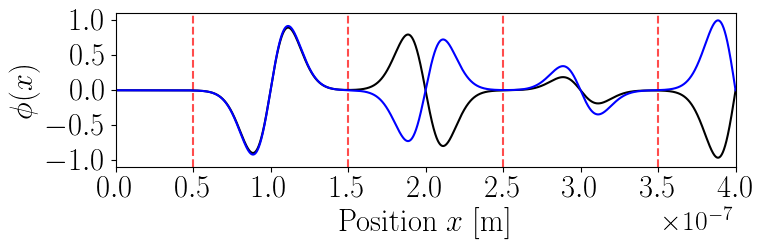

In [14]:
lamb = 100e-9
modevis = 1
nT = int(100)
nTvisu = 4
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
qtesta = (listqa[modevis]+listqb[modevis])/2+(listqa[modevis]-listqb[modevis])/4.5
#qtest = (listqa[modevis]+listqb[modevis])/2
#qtest = listqa[modevis]+1e-9
atesta = 2*s0*qtesta/s1
omega1a = np.sqrt(atesta*(np.pi**2)/(s0*lamb**2))
print(omega1a)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atesta, qtesta))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atesta, qtesta))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValuesa, eigenVectorsa = scipy.linalg.eig(mat_phi)
rho1a = eigenValuesa[0]
rho2a = eigenValuesa[1]

print(rho1a,rho2a)    

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atesta, qtesta))
q0a = solist.y[0,:]
qp0a = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0a)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
#q0adim = np.real(q0)/np.max(peak_amplitudes)
q0adima = np.real(q0a)/np.max(np.abs(np.real(q0a)))
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfunda = peak_wavenumbers[indou]








###########################################################################
qtestb = (listqa[modevis]+listqb[modevis])/2+15e-5
#qtest = listqa[modevis]+1e-9
atestb = 2*s0*qtestb/s1
omega1b = np.sqrt(atestb*(np.pi**2)/(s0*lamb**2))
print(omega1b)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atestb, qtestb))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atestb, qtestb))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValuesb, eigenVectorsb = scipy.linalg.eig(mat_phi)
rho1b = eigenValuesb[0]
rho2b = eigenValuesb[1]

print(rho1b,rho2b)    

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atestb, qtestb))
q0b = solist.y[0,:]
qp0b = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0b)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
#q0adim = np.real(q0)/np.max(peak_amplitudes)
q0adimb = np.real(q0b)/np.max(np.abs(np.real(q0b)))
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfundb = peak_wavenumbers[indou]












fonty = 22
fig5 = plt.figure(5, figsize=(8, 2))

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)
    
# Add vertical dashed lines
for i in range(0, 4):
    x_pos = 0.805*lamb + i * (2*np.pi/np.abs(kfunda))
    #plt.axvline(x=x_pos, color='b', linestyle='--', alpha=0.7)    


plt.plot(listt*lamb/np.pi,q0adima,'k-',linewidth=1.5,label=r'$\rho=-0.444+0.896i$')
plt.plot(listt*lamb/np.pi,q0adimb,'b-',linewidth=1.5,label=r'$\rho=0.211+0.977i$')

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.ylim(-1.1, 1.1)   # set the ylim to ymin, ymax
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty-8,loc='upper left')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Mathieu_mode1.png', format='png', dpi=1000,bbox_inches='tight')



5.490765716084808e+16
(0.44444470950428894+0.8958062995498632j) (0.44444470950428894-0.8958062995498636j)
5.4907657555035624e+16
(-0.5354868908621979+0.8445435527863712j) (-0.5354868908621981-0.8445435527863714j)


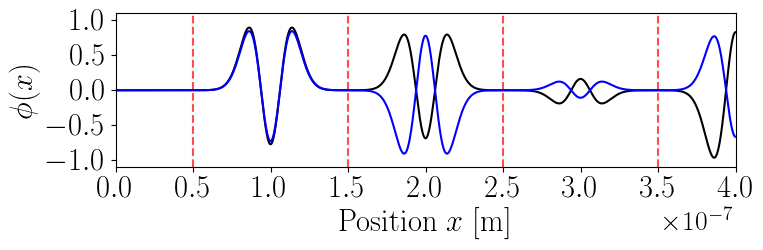

In [15]:
lamb = 100e-9
modevis = 2
nT = int(100)
nTvisu = 4
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
qtesta = (listqa[modevis]+listqb[modevis])/2+(listqa[modevis]-listqb[modevis])/4.5
#qtest = (listqa[modevis]+listqb[modevis])/2
#qtest = listqa[modevis]+1e-9
atesta = 2*s0*qtesta/s1
omega2a = np.sqrt(atesta*(np.pi**2)/(s0*lamb**2))
print(omega2a)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atesta, qtesta))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atesta, qtesta))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValuesa, eigenVectorsa = scipy.linalg.eig(mat_phi)
rho1 = eigenValuesa[0]
rho2 = eigenValuesa[1]

print(rho1,rho2)    

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atesta, qtesta))
q0a = solist.y[0,:]
qp0a = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0a)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
#q0adim = np.real(q0)/np.max(peak_amplitudes)
q0adima = np.real(q0a)/np.max(np.abs(np.real(q0a)))
peak_waveadim2, peak_ampadim2 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfunda = peak_wavenumbers[indou]
















###########################################################################
qtestb = (listqa[modevis]+listqb[modevis])/2+4e-7
#qtest = listqa[modevis]+1e-9
atestb = 2*s0*qtestb/s1
omega2b = np.sqrt(atestb*(np.pi**2)/(s0*lamb**2))
print(omega2b)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atestb, qtestb))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atestb, qtestb))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValuesb, eigenVectorsb = scipy.linalg.eig(mat_phi)
rho1 = eigenValuesb[0]
rho2 = eigenValuesb[1]

print(rho1,rho2)    

solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atestb, qtestb))
q0b = solist.y[0,:]
qp0b = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0b)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
#q0adim = np.real(q0)/np.max(peak_amplitudes)
q0adimb = np.real(q0b)/np.max(np.abs(np.real(q0b)))
peak_waveadim2, peak_ampadim2 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfundb = peak_wavenumbers[indou]













fonty = 22
fig5 = plt.figure(5, figsize=(8, 2))

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)
    
# Add vertical dashed lines
for i in range(0, 4):
    x_pos = 0.805*lamb + i * (2*np.pi/np.abs(kfunda))
    #plt.axvline(x=x_pos, color='b', linestyle='--', alpha=0.7)    

plt.plot(listt*lamb/np.pi,q0adima,'k-',linewidth=1.5,label=r'$\rho=-0.444+0.896i$')
plt.plot(listt*lamb/np.pi,q0adimb,'b-',linewidth=1.5,label=r'$\rho=-0.535+0.844i$')

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.ylim(-1.1,1.1)
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty-8,loc='lower left')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Mathieu_mode2.png', format='png', dpi=1000,bbox_inches='tight')



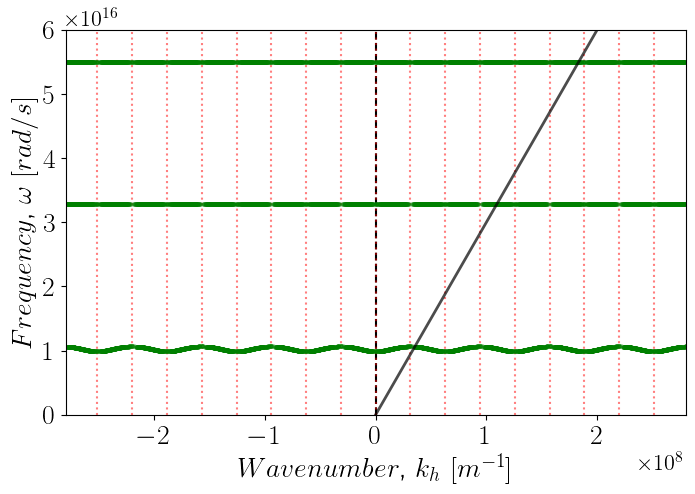

In [16]:
# Define the filter ranges
A, B = -np.pi / lamb, np.pi / lamb  # Example values for the x-axis range
C, D = 0.8e16, 1.5e16   # Example values for the y-axis range

# Create a mask that satisfies both conditions
mask = (np.pi*eigtot1extsort/lamb >= A) & (np.pi*eigtot1extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask2 = (np.pi*eigtot2extsort/lamb >= A) & (np.pi*eigtot2extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)


# Apply the mask to filter the data
Afiltered_eigtot1extsort = eigtot1extsort[mask]
Afiltered_aaextsort1 = aaextsort1[mask]
Afiltered_eigtot2extsort = eigtot2extsort[mask2]
Afiltered_aaextsort2 = aaextsort2[mask2]


# Define the filter ranges
A, B = -2*np.pi / lamb, -np.pi / lamb  # Example values for the x-axis range
C, D = 3e16, 4e16   # Example values for the y-axis range
E, F = np.pi / lamb, 2*np.pi / lamb  # Example values for the x-axis range

# Create a mask that satisfies both conditions
mask = (np.pi*eigtot1extsort/lamb >= A) & (np.pi*eigtot1extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask2 = (np.pi*eigtot2extsort/lamb >= A) & (np.pi*eigtot2extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)
mask3 = (np.pi*eigtot1extsort/lamb >= E) & (np.pi*eigtot1extsort/lamb <= F) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask4 = (np.pi*eigtot2extsort/lamb >= E) & (np.pi*eigtot2extsort/lamb <= F) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)


Bfiltered_eigtot1extsort = eigtot1extsort[mask]
Bfiltered_aaextsort1 = aaextsort1[mask]
Bfiltered_eigtot2extsort = eigtot2extsort[mask2]
Bfiltered_aaextsort2 = aaextsort2[mask2]

Cfiltered_eigtot1extsort = eigtot1extsort[mask3]
Cfiltered_aaextsort1 = aaextsort1[mask3]
Cfiltered_eigtot2extsort = eigtot2extsort[mask4]
Cfiltered_aaextsort2 = aaextsort2[mask4]




# Define the filter ranges
A, B = -3*np.pi / lamb, -2*np.pi / lamb  # Example values for the x-axis range
C, D = 5e16, 6e16   # Example values for the y-axis range
E, F = 2*np.pi / lamb, 3*np.pi / lamb  # Example values for the x-axis range

# Create a mask that satisfies both conditions
mask = (np.pi*eigtot1extsort/lamb >= A) & (np.pi*eigtot1extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask2 = (np.pi*eigtot2extsort/lamb >= A) & (np.pi*eigtot2extsort/lamb <= B) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)
mask3 = (np.pi*eigtot1extsort/lamb >= E) & (np.pi*eigtot1extsort/lamb <= F) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb <= D)
mask4 = (np.pi*eigtot2extsort/lamb >= E) & (np.pi*eigtot2extsort/lamb <= F) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb >= C) & (np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb <= D)


Dfiltered_eigtot1extsort = eigtot1extsort[mask]
Dfiltered_aaextsort1 = aaextsort1[mask]
Dfiltered_eigtot2extsort = eigtot2extsort[mask2]
Dfiltered_aaextsort2 = aaextsort2[mask2]

Efiltered_eigtot1extsort = eigtot1extsort[mask3]
Efiltered_aaextsort1 = aaextsort1[mask3]
Efiltered_eigtot2extsort = eigtot2extsort[mask4]
Efiltered_aaextsort2 = aaextsort2[mask4]














ymax = 1.05*np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)
ymax = 6e16
fonty = 20
fig3 = plt.figure(3, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.axvline(x=0, color='k', linestyle='--', alpha=1)
# Add vertical dashed lines
for i in range(-50,50):
    x_pos = i * np.pi / lamb
    plt.axvline(x=x_pos, color='r', linestyle=':', alpha=0.5)

plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.,markersize=5, alpha=0.3)
plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.,markersize=5, alpha=0.3)
#plt.plot(np.pi*Afiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Afiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Afiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Afiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Bfiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Bfiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Bfiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Bfiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Cfiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Cfiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Cfiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Cfiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Dfiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Dfiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Dfiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Dfiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Efiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Efiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Efiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Efiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=2.,alpha=0.7)
#plt.plot(peak_waveadim2, omega2*np.ones(peak_waveadim2.size),'sk',markersize=8)
#plt.plot(peak_waveadim1, omega1*np.ones(peak_waveadim1.size),'.k',markersize=18)
#plt.plot(peak_waveadim0, omega0*np.ones(peak_waveadim0.size),'xk',markersize=12)
#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel(r'$Wavenumber$, $k_h$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$, $\omega$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)
ax.yaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlim(-1.4*kmax, 1.4*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

fig3.savefig('Dispersion_relation.png', format='png', dpi=1000, bbox_inches='tight')

### → Figure S3 — Multi-configuration Bloch waves

Computes wave solutions for four frequency samples (configs a–d) inside the
first pass band to illustrate the near-degeneracy in the narrow-pass-band limit.


Omega a: 3.280943241770208e+16
Rho1 a: (-0.6000636093647217+0.7999522889969031j)
Rho2 a: (-0.6000636093647216-0.799952288996903j)
Omega b: 3.2809569236990572e+16
Rho1 b: (-0.2000954154786635+0.979776415663156j)
Rho2 b: (-0.20009541547866344-0.9797764156631561j)
Omega c: 3.2809706055708516e+16
Rho1 c: (0.19990458293832136+0.9798153692074818j)
Rho2 c: (0.1999045829383215-0.9798153692074818j)
Omega d: 3.280984287385592e+16
Rho1 d: (0.5999363875444543+0.8000477053853305j)
Rho2 d: (0.5999363875444544-0.8000477053853305j)


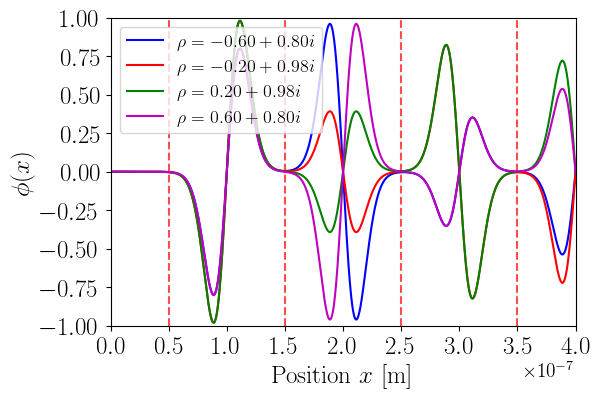

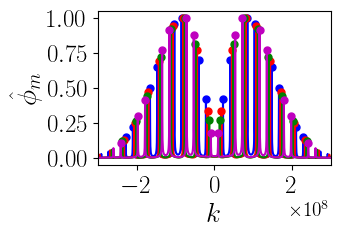

4651388.203220275
3819224.920598079
3843829.085430375
4889147.563330488
4300897.443144804
3.280963764606427e+16
476917.6761761521
152967976961.52643


In [17]:
modevis = 1
configs = ['a', 'b', 'c', 'd']
omegas = {}  # To store computed omega values
rho1s = {}  # To store computed omega values
rho2s = {}
q0_results = {}  # To store the wave solutions (q0)
fft_results = {}  # To store FFT results for plotting

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

lamb = 100e-9
nT = int(120)
nTvisu = 4
y0 = np.array([0.1,-0.2])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)
L = np.max(listt * lamb / np.pi)

# Configuration-specific computations
#for config in configs:
#    if config == 'a':
#        qtest = (listqa[modevis] + listqb[modevis]) / 2 - (listqa[modevis] - listqb[modevis]) / 3
#    elif config == 'b':
#        qtest = (listqa[modevis] + listqb[modevis]) / 2 + (listqa[modevis] - listqb[modevis]) / 5
#    elif config == 'c':
#        qtest = (listqa[modevis] + listqb[modevis]) / 2 + (listqa[modevis] - listqb[modevis]) / 3
#    elif config == 'd':
#        qtest = (listqa[modevis] + listqb[modevis]) / 2 - (listqa[modevis] - listqb[modevis]) / 5

# Configuration-specific computations
for config in configs:
    if config == 'a':
        qtest = listqa[modevis] + 0.2*(listqb[modevis] - listqa[modevis])
    elif config == 'b':
        qtest = listqa[modevis] + 0.4*(listqb[modevis] - listqa[modevis])
    elif config == 'c':
        qtest = listqa[modevis] + 0.6*(listqb[modevis] - listqa[modevis])
    elif config == 'd':
        qtest = listqa[modevis] + 0.8*(listqb[modevis] - listqa[modevis])
        
        
    atest = 2 * s0 * qtest / s1
    omega = np.sqrt(atest * (np.pi ** 2) / (s0 * lamb ** 2))
    omegas[config] = omega
    print(f"Omega {config}: {omega}")

    solist = solve_ivp(
        equation_lin, [0, np.pi * nT - dt], y0, method='DOP853',
        rtol=1e-14, atol=1e-18, t_eval=listt, args=(atest, qtest)
    )
    q0 = solist.y[0, :]
    
    sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
    sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
# Assembly of the monodromy matrix Phi
    mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
    eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
    rho1s[config] = eigenValues[0]
    rho2s[config] = eigenValues[1]
    print(f"Rho1 {config}: {eigenValues[0]}")
    print(f"Rho2 {config}: {eigenValues[1]}")

    # FFT Analysis
    wave = np.real(q0)
    N_wave = len(wave)
    fft_wave = np.fft.fft(wave) / N_wave  # Normalize
    k = 2 * np.pi * np.fft.fftfreq(N_wave, d=L / N_wave)
    k = np.fft.fftshift(k)
    fft_wave_shifted = np.fft.fftshift(fft_wave)

    # Find peaks
    peak_wavenumbers, peak_amplitudes = find_fft_peaks(
        np.abs(fft_wave_shifted), k, height=0.5, distance=1
    )
    
    fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
    q0adim = np.real(q0)/np.max(peak_amplitudes)
    #q0adim = np.real(q0)/np.max(peak_amplitudes)
    q0adim = np.real(q0)/np.max(np.abs(np.real(q0)))
    q0_results[config] = np.real(q0adim)  # Store the wave solution for each configuration
    peak_waveadim, peak_ampadim = find_fft_peaks(fftadim, k, height=0.1, distance=1)

    # Store FFT results for plotting
    fft_results[config] = {
        'k': k, 'fft': fftadim, 'peaks': (peak_waveadim, peak_ampadim)
    }
    
maxou = np.max(np.concatenate([fft_results['a']['fft'],fft_results['b']['fft'],fft_results['c']['fft'],fft_results['d']['fft']]))
#maxou = 1

# Plot 1: q0 vs Position x
fonty = 18
fig1 = plt.figure(1, figsize=(6, 4))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)

colors = {'a': 'b', 'b': 'r', 'c': 'g', 'd': 'm'}
laboul = [r'$\rho=-0.60+0.80i$', r'$\rho=-0.20+0.98i$', r'$\rho=0.20+0.98i$', r'$\rho=0.60+0.80i$']  # Since it's a set, duplicate values will be removed
incai = -1
for config in configs:
    incai = incai+1
    plt.plot(listt * lamb / np.pi, q0_results[config]/maxou, f'{colors[config]}-', linewidth=1.5, label=laboul[incai])

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlim(0, nTvisu * lamb)
plt.ylim(-1, 1)
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
# Add legend
plt.legend(fontsize=fonty-5, loc='upper left')
plt.show()



fig1.savefig('Mutli_phi_mode3.png', format='png', dpi=1000, bbox_inches='tight')


ind1 = np.argmin(np.abs(listt* lamb / np.pi - 0.5*lamb))
ind2 = np.argmin(np.abs(listt* lamb / np.pi - 1.5*lamb))
listcell = listt[ind1:ind2]*lamb/np.pi
qcell = q0_results[config][ind1:ind2]

# Plot 2: FFT Amplitude vs Wavenumber
fig2 = plt.figure(2, figsize=(3, 2))
incai = -1
for config in configs:
    incai = incai + 1
    fft_res = fft_results[config]
    plt.plot(fft_res['k'], fft_res['fft']/maxou, f'{colors[config]}-', label=laboul[incai])
    plt.plot(fft_res['peaks'][0], fft_res['peaks'][1]/maxou, f'.{colors[config]}', markersize=10)
    #plt.plot((listcell-lamb)*1.42e16, qcell**2/5e11)

    
# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)

#plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlabel(r'$k$',fontsize=fonty+2)
plt.ylabel(r'$\hat{\phi}_m$',fontsize=fonty+2)
plt.xlim(-1.5*kmax, 1.5*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
# Add legend
#plt.legend(fontsize=fonty-5, loc='upper left')
plt.show()


fig2.savefig('Mutli_phi_FFT_mode3.png', format='png', dpi=1000, bbox_inches='tight')



energs = {}
# Configuration-specific computations
for config in configs:
    fft_res = fft_results[config]
    energ = compute_energy(fft_res['fft']/maxou,fft_res['k'])
    print(energ)
    energs[config] = energ

print(np.mean([energs['a'],energs['b'],energs['c'],energs['d']]))
print(np.mean([omegas['a'],omegas['b'],omegas['c'],omegas['d']]))
print(np.std([energs['a'],energs['b'],energs['c'],energs['d']]))
print(np.std([omegas['a'],omegas['b'],omegas['c'],omegas['d']]))


### → Figure S3 — Dispersion relation in the extended Brillouin zone

Plots $\omega$ vs $k$ in the extended zone scheme. In the narrow-pass-band limit,
the pass-band branches collapse onto the quantized levels
$\omega_n \approx \left(n+\tfrac{1}{2}\right)\omega_0$.


a
3.280943241770208e+16
b
3.2809569236990572e+16
c
3.2809706055708516e+16
d
3.280984287385592e+16


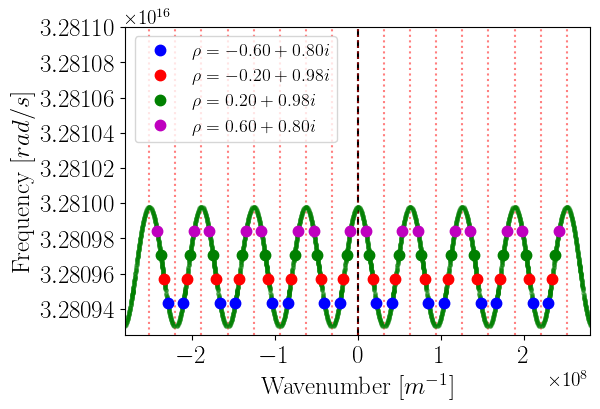

In [18]:
ymax = 1.05*np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)
ymax = 6e16
fonty = 18
fig3 = plt.figure(3, figsize=(6, 4))
plt.rc('text', usetex=True)

plt.axvline(x=0, color='k', linestyle='--', alpha=1)
# Add vertical dashed lines
for i in range(-50,50):
    x_pos = i * np.pi / lamb
    plt.axvline(x=x_pos, color='r', linestyle=':', alpha=0.5)

plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.,markersize=5, alpha=0.3)
plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.,markersize=5, alpha=0.3)
#plt.plot(np.pi*Bfiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Bfiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Bfiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Bfiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Cfiltered_eigtot1extsort/lamb, np.pi*np.sqrt(Cfiltered_aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*Cfiltered_eigtot2extsort/lamb, np.pi*np.sqrt(Cfiltered_aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'b.',linewidth=1.,markersize=8)
#plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
#plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=2.,alpha=0.7)
incou = -1
for config in configs:
    print(config)
    incou = incou + 1
    fft_res = fft_results[config]
    plt.plot(fft_res['peaks'][0], omegas[config]*np.ones(fft_res['peaks'][0].size),f'{colors[config]}.', markersize=15,label=laboul[incou])
    print(omegas[config])

legend = plt.legend(fontsize=fonty-5,loc='upper left')
plt.xlabel(r'$\mathrm{Wavenumber}$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Frequency}$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)
ax.yaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlim(-1.4*kmax, 1.4*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(3.280925e16, 3.2811e16)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

fig3.savefig('Dispersion_relation_zoom.png', format='png', dpi=1000, bbox_inches='tight')

## By Arnaud Lazarus - 06/13/2026